## Benchmark bar plots

### AUPR

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# Extracting the data and converting to a DataFrame for easy plotting
data_bars_aupr = {
    "Cancer Type": ["BRCA", "CESC", "COAD", "KIRC", "LAML", "LUAD", "SKCM", "OV"],
    "GCATSL": [0.9648, 0.2020, 0.0700, 0.1842, 0.2450, 0.5685, 0.1782, None],
    "ELISL": [0.8961, 0.1279, 0.0921, 0.0696, 0.1658, 0.5311, 0.0741, 0.8028],
    "KG4SL": [0.9626, 0.1850, 0.0540, 0.0760, 0.2191, 0.5261, 0.1530, 0.3834],
    "Geneformer Probing": [0.9237, 0.1567, 0.0734, 0.0752, 0.2076, 0.5853, 0.1706, 0.7697],
    "MVGCN-iSL": [0.8368, 0.1076, 0.0545, 0.1118, 0.1781, 0.5078, 0.1215, 0.5833],
    "SLformer": [0.9488, 0.2070, 0.0807, 0.2693, 0.2079, 0.6086, 0.2015, 0.9456]
}

# Convert to a DataFrame
df_bars = pd.DataFrame(data_bars_aupr)

# Flatten the data to have a single column of values and another for labels
df_melted = df_bars.melt(id_vars=["Cancer Type"], var_name="Model", value_name="AUPR")

# Remove None values
df_melted = df_melted.dropna()

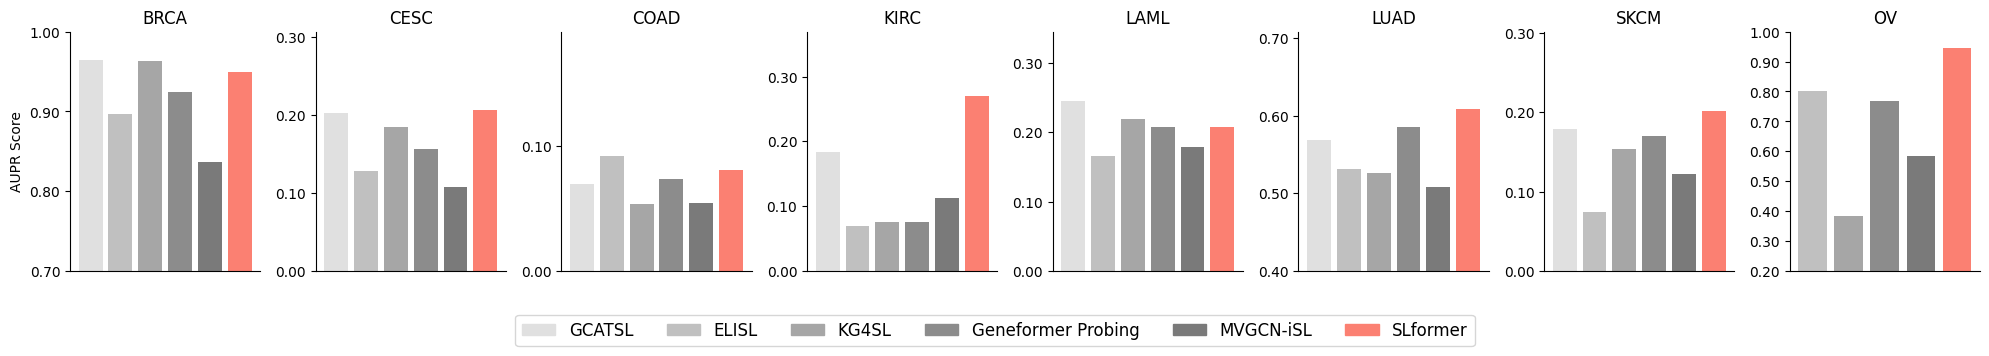

In [ ]:

from matplotlib.ticker import FuncFormatter
import matplotlib.patches as mpatches
import numpy as np

def two_decimals(x, pos):
    return f'{x:.2f}'

# Create 8 subplots in one row
fig, axes = plt.subplots(1, 8, figsize=(20, 3))  # 1 row and 8 columns for 8 subplots
axes = axes.flatten()

# List of cancer types and models
cancer_types = data_bars_aupr["Cancer Type"]
models = ["GCATSL","ELISL", "KG4SL","Geneformer", "MVGCN-iSL",   "SLformer"]

model_colors = {
    "GCATSL": '#e0e0e0',
    "ELISL": '#c0c0c0',
    "KG4SL": '#a6a6a6',
    "Geneformer Probing": '#8c8c8c',
    "MVGCN-iSL": '#7a7a7a',
    "SLformer": '#fb8072'
}


interval = 0.1
y_ticks_all = np.arange(0, 1.05, interval)  # Possible y-ticks from 0 to 1 with a step of 0.1

# Loop through each cancer type and create a subplot without sorting
for i, cancer in enumerate(cancer_types):
    # Filter data for each cancer
    df_cancer = df_melted[df_melted["Cancer Type"] == cancer]
    
    # Set min_value as a multiple of 0.1
    raw_min_value = df_cancer["AUPR"].min() - 0.1
    min_value = np.floor(raw_min_value / interval) * interval  # Adjust to nearest multiple of 0.1
    min_value = max(min_value, 0)  # Ensure it's not below 0
    max_value = min(df_cancer["AUPR"].max() + 0.1, 1)
    
    # Plotting (using colors and adding axis ticks/labels)
    axes[i].bar(range(len(df_cancer)), df_cancer["AUPR"], color=[model_colors[model] for model in df_cancer['Model']])
    axes[i].set_title(f'{cancer}')
    axes[i].set_ylim(min_value, max_value)  
    
    axes[i].yaxis.set_major_formatter(FuncFormatter(two_decimals))

    # Adding specific axis labels and ticks to each subplot
    axes[i].set_xticks([])
    if i == 0:
        axes[i].set_ylabel("AUPR Score")  # Only first plot has y-label
        
    # Select y-ticks within the range and ensure min_value is included
    y_ticks = y_ticks_all[(y_ticks_all >= min_value) & (y_ticks_all <= max_value)]
    # if min_value not in y_ticks and i != 7:
    #     y_ticks = np.append(y_ticks, min_value)  # Add min_value as a tick mark if it's not already included
    axes[i].set_yticks(np.sort(y_ticks))  # Sort to ensure the order is correct

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Create a single legend for all subplots
legend_handles = [mpatches.Patch(color=color, label=model) for model, color in model_colors.items()]
fig.legend(handles=legend_handles, loc="lower center", ncol=len(models), bbox_to_anchor=(0.5, -0.2), fontsize=12)

# fig.suptitle('Performance Comparison in Cancer-specific Case', fontsize=16)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()




['GCATSL', 'ELISL', 'KG4SL', 'Geneformer Probing', 'MVGCN-iSL', 'SLformer']


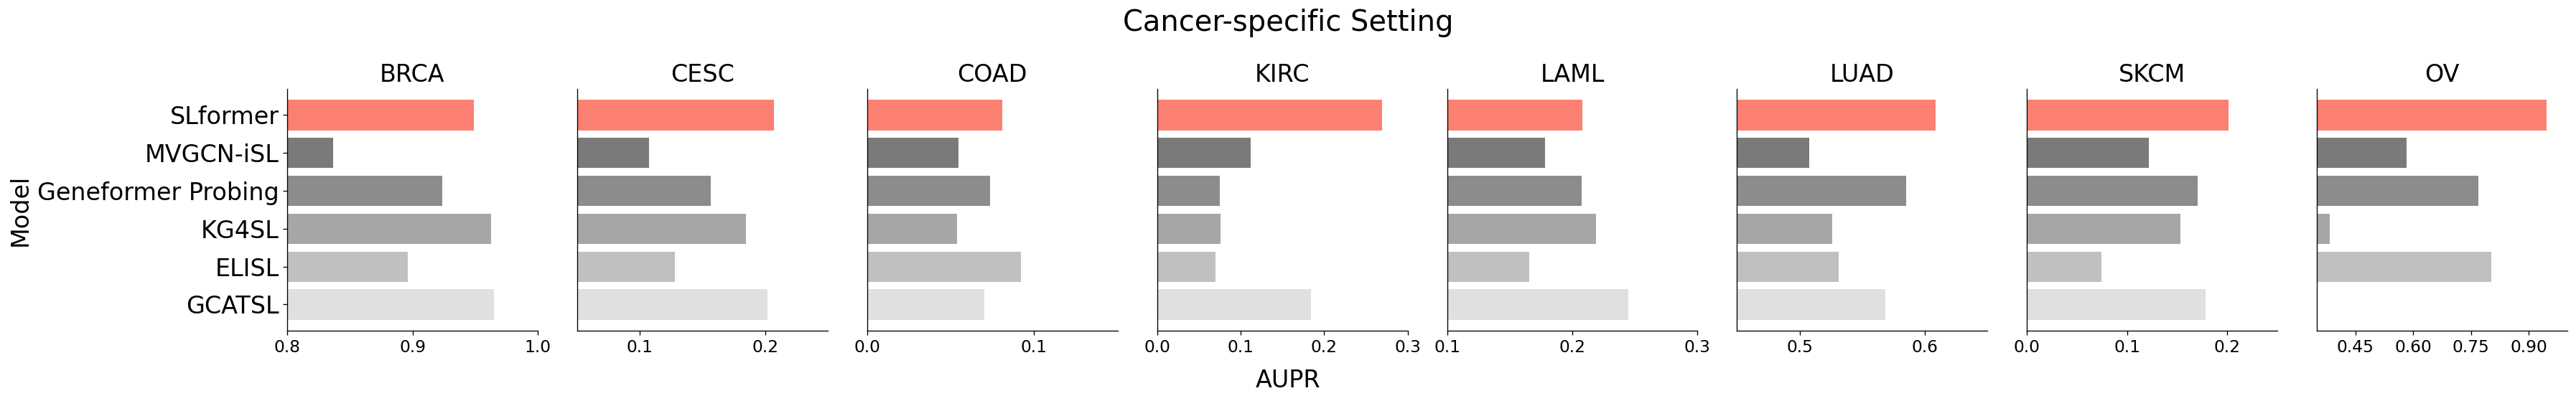

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# Data
data_bars_aupr = {
    "Cancer Type": ["BRCA", "CESC", "COAD", "KIRC", "LAML", "LUAD", "SKCM", "OV"],
    "GCATSL": [0.9648, 0.2020, 0.0700, 0.1842, 0.2450, 0.5685, 0.1782, None],
    "ELISL": [0.8961, 0.1279, 0.0921, 0.0696, 0.1658, 0.5311, 0.0741, 0.8028],
    "KG4SL": [0.9626, 0.1850, 0.0540, 0.0760, 0.2191, 0.5261, 0.1530, 0.3834],
    "Geneformer Probing": [0.9237, 0.1567, 0.0734, 0.0752, 0.2076, 0.5853, 0.1706, 0.7697],
    "MVGCN-iSL": [0.8368, 0.1076, 0.0545, 0.1118, 0.1781, 0.5078, 0.1215, 0.5833],
    "SLformer": [0.9488, 0.2070, 0.0807, 0.2693, 0.2079, 0.6086, 0.2015, 0.9456]
}

# Order
# models = list(data_bars_aupr.keys())[1:][::-1]  # reverse the model order
models = list(data_bars_aupr.keys())[1:]
print(models)
cancer_types = data_bars_aupr["Cancer Type"]

# Colors
model_colors = {
    "GCATSL": '#e0e0e0',
    "ELISL": '#c0c0c0',
    "KG4SL": '#a6a6a6',
    "Geneformer Probing": '#8c8c8c',
    "MVGCN-iSL": '#7a7a7a',
    "SLformer": '#fb8072'
}

missing_color = "#ffffff"  # white for missing bars

# Set up figure
fig, axes = plt.subplots(1, 8, figsize=(30, 4.4), dpi=120)
axes = axes.flatten()

# Plotting loop
for i, cancer in enumerate(cancer_types):
    
    ax = axes[i]
    
    # Extract AUPR values
    auprs = [data_bars_aupr[model][i] for model in models]
    subset = pd.DataFrame({
        "Model": models,
        "AUPR": auprs
    })

    # Determine x-axis limits based only on non-None values
    valid_auprs = subset["AUPR"].dropna()
    if valid_auprs.empty:
        ax.axis('off')
        continue
    
    per_step = 0.05
    x_margin = 0.03  # slight margin to avoid tight fit

    x_min = max(0, np.floor((valid_auprs.min() - x_margin) / per_step) * per_step)
    x_max = min(1, np.ceil((valid_auprs.max() + x_margin) / per_step) * per_step)

    if x_min == x_max:
        x_max += per_step
        
    # Special rule for last subplot (OV)

    if cancer == "KIRC":
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1)) # 0.15
    elif cancer == "OV":
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.15)) # 0.15
    else:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
        
    ax.set_xlim(x_min, x_max)
    ax.set_title(cancer, fontsize=20)

    # Plot bars one by one to handle None values
    for j, row in subset.iterrows():
        model = row["Model"]
        value = row["AUPR"]
        color = model_colors[model] if pd.notnull(value) else missing_color
        ax.barh(model, value if pd.notnull(value) else 0, color=color)

    if i != 0:
        ax.set_yticks([])
    else:
        ax.set_ylabel("Model", fontsize=20)
        ax.tick_params(axis='y', labelsize=20)  # Set y-axis (model names) font size

    ax.tick_params(axis='x', labelsize=14)
    # Show only left and bottom spines
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)


# Global x-label
fig.text(0.5, 0.00, 'AUPR', ha='center', fontsize=20)
# Global figure title
# fig.suptitle("Performance Comparison in Cancer-specific Setting", fontsize=24, y=1.0)
fig.suptitle("Cancer-specific Setting", fontsize=24, y=1.0)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


### F1

In [10]:
data_bars_f1 = {
    "Cancer Type": ["BRCA", "CESC", "COAD", "KIRC", "LAML", "LUAD", "SKCM", "OV"],
    "GCATSL": [0.9241, 0.3275, 0.1174, 0.3227, 0.2815, 0.6796, 0.2854, None],
    "ELISL": [0.8263, 0.2184, 0.1492, 0.1563, 0.1984, 0.6168, 0.1893, 0.7905],
    "KG4SL": [0.9249, 0.3093, 0.0988, 0.2089, 0.2532, 0.6350, 0.2667, 0.5428],
    "Geneformer Probing": [0.8556, 0.2693, 0.1119, 0.1851, 0.231, 0.651, 0.2624, 0.7294],
    "MVGCN-iSL": [0.7879, 0.1782, 0.1057, 0.2065, 0.2138, 0.6336, 0.2334, 0.6363],
    "SLformer": [0.9017, 0.3373, 0.1346, 0.4661, 0.2355, 0.6541, 0.2939, 0.9115]
}


# Convert to a DataFrame
df_bars = pd.DataFrame(data_bars_f1)

# Flatten the data to have a single column of values and another for labels
df_melted = df_bars.melt(id_vars=["Cancer Type"], var_name="Model", value_name="F1")

# Remove None values
df_melted = df_melted.dropna()


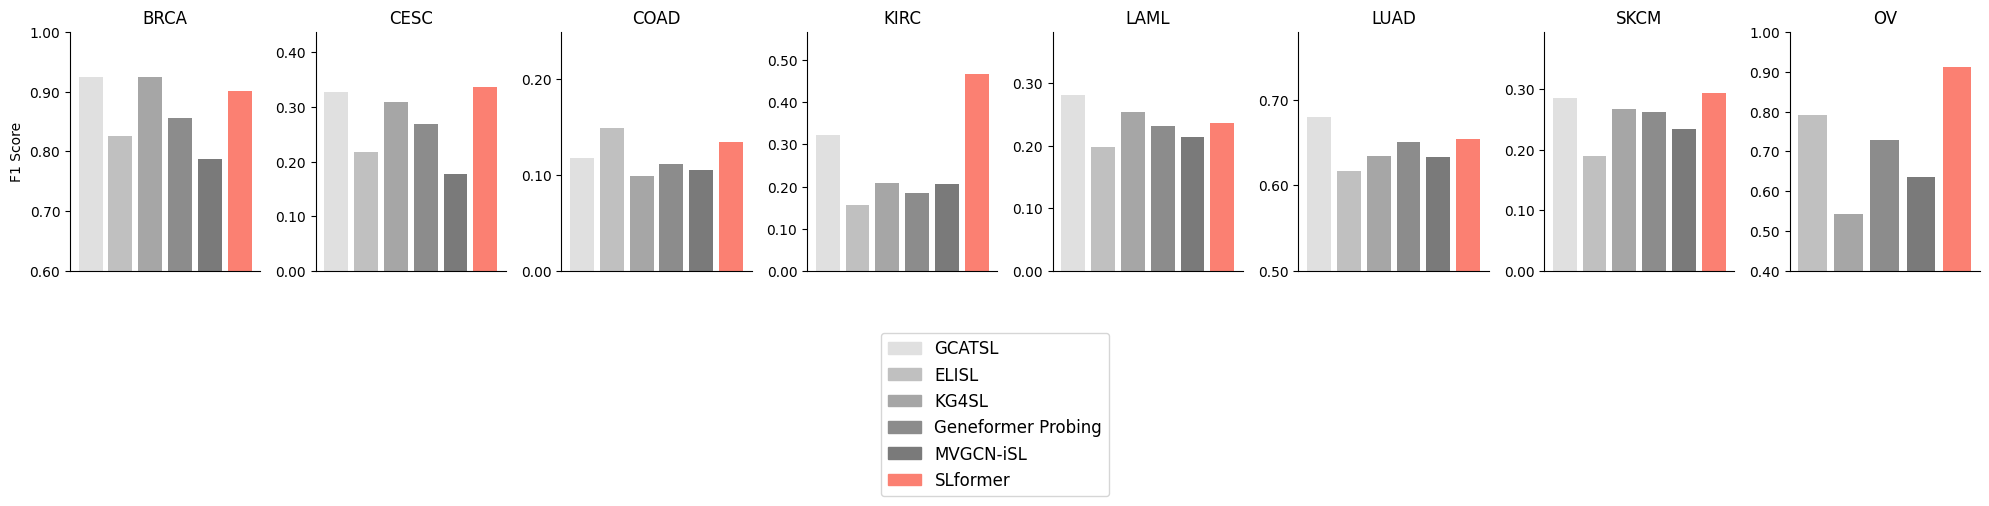

In [11]:
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as mpatches
import numpy as np

def two_decimals(x, pos):
    return f'{x:.2f}'

# Create 8 subplots in one row
fig, axes = plt.subplots(1, 8, figsize=(20, 3))  # 1 row and 8 columns for 8 subplots
axes = axes.flatten()

# List of cancer types and models
cancer_types = data_bars_f1["Cancer Type"]
models = ["GCATSL", "KG4SL", "MVGCN-iSL", "ELISL", "Geneformer Probing", "SLformer"]


interval = 0.1
y_ticks_all = np.arange(0, 1.05, interval)  # Possible y-ticks from 0 to 1 with a step of 0.1

# Loop through each cancer type and create a subplot without sorting
for i, cancer in enumerate(cancer_types):
    # Filter data for each cancer
    df_cancer = df_melted[df_melted["Cancer Type"] == cancer]
    
    # Set min_value as a multiple of 0.1
    raw_min_value = df_cancer["F1"].min() - 0.1
    min_value = np.floor(raw_min_value / interval) * interval  # Adjust to nearest multiple of 0.1
    min_value = max(min_value, 0)  # Ensure it's not below 0

    max_value = min(df_cancer["F1"].max() + 0.1, 1)
    
    # Plotting (using colors and adding axis ticks/labels)
    axes[i].bar(range(len(df_cancer)), df_cancer["F1"], color=[model_colors[model] for model in df_cancer['Model']])
    axes[i].set_title(f'{cancer}')
    axes[i].set_ylim(min_value, max_value)  
    
    axes[i].yaxis.set_major_formatter(FuncFormatter(two_decimals))

    # Adding specific axis labels and ticks to each subplot
    axes[i].set_xticks([])
    if i == 0:
        axes[i].set_ylabel("F1 Score")  # Only first plot has y-label
        
    # Select y-ticks within the range and ensure min_value is included
    y_ticks = y_ticks_all[(y_ticks_all >= min_value) & (y_ticks_all <= max_value)]
    # if min_value not in y_ticks and i != 4 and i != 6:
    #     y_ticks = np.append(y_ticks, min_value)  # Add min_value as a tick mark if it's not already included
    axes[i].set_yticks(np.sort(y_ticks))  # Sort to ensure the order is correct

    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Create a single legend for all subplots
legend_handles = [mpatches.Patch(color=color, label=model) for model, color in model_colors.items()]
# fig.legend(handles=legend_handles, loc="lower center", ncol=len(models), bbox_to_anchor=(0.5, -0.2), fontsize=12)
fig.legend(handles=legend_handles,  ncol=1, bbox_to_anchor=(0.5, -0.4), loc="center", fontsize=12)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()




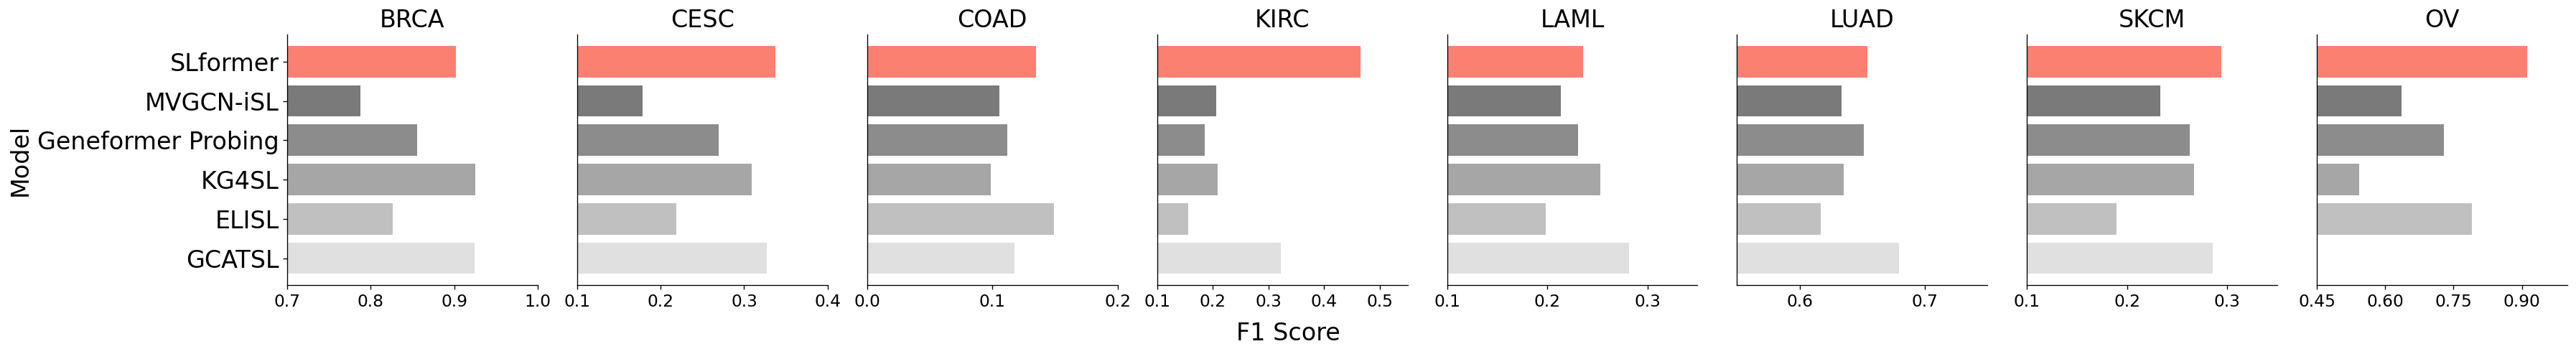

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# F1 Score Data
data_bars_f1 = {
    "Cancer Type": ["BRCA", "CESC", "COAD", "KIRC", "LAML", "LUAD", "SKCM", "OV"],
    "GCATSL": [0.9241, 0.3275, 0.1174, 0.3227, 0.2815, 0.6796, 0.2854, None],
    "ELISL": [0.8263, 0.2184, 0.1492, 0.1563, 0.1984, 0.6168, 0.1893, 0.7905],
    "KG4SL": [0.9249, 0.3093, 0.0988, 0.2089, 0.2532, 0.6350, 0.2667, 0.5428],
    "Geneformer Probing": [0.8556, 0.2693, 0.1119, 0.1851, 0.231, 0.651, 0.2624, 0.7294],
    "MVGCN-iSL": [0.7879, 0.1782, 0.1057, 0.2065, 0.2138, 0.6336, 0.2334, 0.6363],
    "SLformer": [0.9017, 0.3373, 0.1346, 0.4661, 0.2355, 0.6541, 0.2939, 0.9115]
}

# Order
# models = list(data_bars_f1.keys())[1:][::-1]  # reverse the model order
models = list(data_bars_f1.keys())[1:]
cancer_types = data_bars_f1["Cancer Type"]

# Colors
model_colors = {
    "GCATSL": '#e0e0e0',
    "ELISL": '#c0c0c0',
    "KG4SL": '#a6a6a6',
    "Geneformer Probing": '#8c8c8c',
    "MVGCN-iSL": '#7a7a7a',
    "SLformer": '#fb8072'
}
missing_color = "#ffffff"  # white for missing bars

# Set up figure
fig, axes = plt.subplots(1, 8, figsize=(30, 4), dpi=120)
axes = axes.flatten()

# Plotting loop
for i, cancer in enumerate(cancer_types):
    ax = axes[i]

    # Extract F1 values
    f1s = [data_bars_f1[model][i] for model in models]
    subset = pd.DataFrame({
        "Model": models,
        "F1": f1s
    })

    # Determine valid F1 range
    valid_f1s = subset["F1"].dropna()
    if valid_f1s.empty:
        ax.axis('off')
        continue

    base_step = 0.05
    x_margin = 0.05

    x_min = max(0, np.floor((valid_f1s.min() - x_margin) / base_step) * base_step)
    x_max = min(1, np.ceil((valid_f1s.max() + x_margin) / base_step) * base_step)
    if x_min == x_max:
        x_max += base_step

    # Adjust tick step for OV if needed
    if cancer == "OV":
            ax.xaxis.set_major_locator(ticker.MultipleLocator(0.15))
    elif cancer == "KIRC" or cancer =="BRCA" or cancer =="CESC" or cancer =="LAML" or cancer =="SKCM":
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
    else:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))

    ax.set_xlim(x_min, x_max)
    ax.set_title(cancer, fontsize=20)

    for j, row in subset.iterrows():
        model = row["Model"]
        value = row["F1"]
        color = model_colors[model] if pd.notnull(value) else missing_color
        ax.barh(model, value if pd.notnull(value) else 0, color=color)

    if i != 0:
        ax.set_yticks([])
    else:
        ax.set_ylabel("Model", fontsize=20)
        ax.tick_params(axis='y', labelsize=20)

    # Tick font size (x-axis)
    ax.tick_params(axis='x', labelsize=14)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# Global x-label
fig.text(0.5, 0.0, 'F1 Score', ha='center', fontsize=20)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


### Mixed

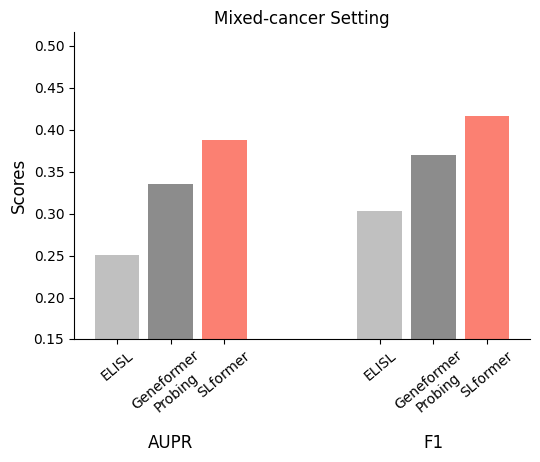

In [89]:

import numpy as np
import matplotlib.pyplot as plt

# Define the metrics and data for each model
metrics = ["AUPR", "F1"]
# models = ["Geneformer", "ELISL", "SLformer"]
models = ["ELISL", "Geneformer Probing", "SLformer"]

# Replace long names with multi-line versions
pretty_model_names = {
    "ELISL": "ELISL",
    "Geneformer Probing": "Geneformer\nProbing",
    "SLformer": "SLformer"
}

model_colors = {
    "GCATSL": '#e0e0e0',
    "ELISL": '#c0c0c0',
    "KG4SL": '#a6a6a6',
    "Geneformer Probing": '#8c8c8c',
    "MVGCN-iSL": '#7a7a7a',
    "SLformer": '#fb8072'
}

# Scores for each metric
# aupr_scores = [0.3356, 0.2513, 0.3879]
# f1_scores = [0.37, 0.3035, 0.4162]
aupr_scores = [0.2513, 0.3356, 0.3879]
f1_scores = [0.3035, 0.37, 0.4162]

# Group the scores
scores = [aupr_scores, f1_scores]

colors = [model_colors['ELISL'],model_colors['Geneformer Probing'], model_colors['SLformer']]

# Create figure and axis
fig, ax = plt.subplots(figsize=(5.5, 5))

# X positions for bars
x = np.arange(len(metrics))

# Bar width
bar_width = 0.17

# Positions of the bars for each model
positions = [x - bar_width*1.2, x, x + bar_width*1.2]


# Determine min and max values from scores
min_value = min(min(aupr_scores), min(f1_scores)) - 0.1
max_value = max(max(aupr_scores), max(f1_scores)) + 0.1

# Make sure min_value is not less than 0
min_value = max(min_value, 0)
max_value = min(max_value, 1)

# Generate y-ticks dynamically from 0 to max_value at intervals of 0.05
y_ticks_all = np.arange(0, 1.05, 0.05)
y_ticks = y_ticks_all[(y_ticks_all >= min_value) & (y_ticks_all <= max_value)]
if min_value not in y_ticks:
    y_ticks = np.append(y_ticks, min_value)  # Add min_value to y-ticks if not present

# Plot bars without error bars
for i, model in enumerate(models):
    ax.bar(positions[i], [scores[0][i], scores[1][i]], 
           width=bar_width, label=model, color=colors[i])

# Set labels and title
ax.set_ylabel('Scores', fontsize=12)
# ax.set_title('Performance Comparison in Mixed-cancer Setting')
ax.set_title('Mixed-cancer Setting')


# **Set first row of x-axis labels (model names)**
xtick_labels = [pretty_model_names[model] for model in models for _ in metrics]

flattened_positions = np.concatenate(positions)  # All individual bar positions
ax.set_xticks(flattened_positions)  
ax.set_xticklabels(xtick_labels, rotation=40)  # Repeat model names for each metric

# **Add second row of x-axis labels (metric names)**
for i, metric in enumerate(metrics):
    ax.text(x[i], min_value - 0.13, metric, ha='center', fontsize=12)


# Set the y-axis limits and ticks
ax.set_ylim(min_value, max_value)
ax.set_yticks(np.sort(y_ticks))

# Format the y-axis tick labels to two decimal places
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
    
# Add legend below the plot
# legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in colors]
# fig.legend(legend_handles, labels=models, loc="lower center", ncol=len(models), bbox_to_anchor=(0.5, -0.2), fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()


/tmp/ipykernel_1645514/69031401.py:59: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
/tmp/ipykernel_1645514/69031401.py:59: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')


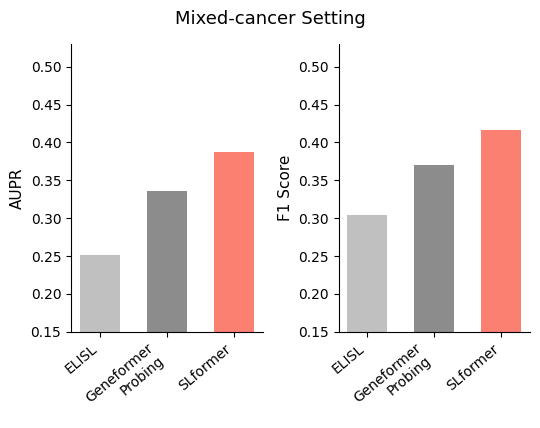

In [131]:
## 2 subplots

import numpy as np
import matplotlib.pyplot as plt

# Data setup
models = ["ELISL", "Geneformer Probing", "SLformer"]
pretty_model_names = {
    "ELISL": "ELISL",
    "Geneformer Probing": "Geneformer\nProbing",
    "SLformer": "SLformer"
}

model_colors = {
    "GCATSL": '#e0e0e0',
    "ELISL": '#c0c0c0',
    "KG4SL": '#a6a6a6',
    "Geneformer Probing": '#8c8c8c',
    "MVGCN-iSL": '#7a7a7a',
    "SLformer": '#fb8072'
}

# Scores
aupr_scores = [0.2513, 0.3356, 0.3879]
f1_scores = [0.3035, 0.37, 0.4162]
scores = [aupr_scores, f1_scores]
metrics = ["AUPR", "F1"]

# Colors in order
colors = [model_colors[model] for model in models]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(5.5, 4.6)) # 5.5, 4.3

min_val = 0.15
max_val = 0.53

for idx, ax in enumerate(axes):
    metric = metrics[idx]
    metric_scores = scores[idx]

    # Y limits and ticks
    # min_val = max(min(metric_scores) - 0.1, 0)
    # max_val = min(max(metric_scores) + 0.1, 1)
    y_ticks = np.arange(0, 1.05, 0.05)
    y_ticks = y_ticks[(y_ticks >= min_val) & (y_ticks <= max_val)]

    # Plot bars
    for i, model in enumerate(models):
        ax.bar(pretty_model_names[model], metric_scores[i], color=colors[i], width=0.6)

    # ax.set_title(metric, fontsize=14)
    ax.set_ylabel("AUPR" if metric == "AUPR" else "F1 Score", fontsize=11)
    ax.set_ylim(min_val, max_val)
    ax.set_yticks(np.sort(y_ticks))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

    ax.tick_params(axis='x', labelsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')

    # Add metric label below the ticks (second row x-label)
    # ax.text(0.5, -0.28, metric, transform=ax.transAxes, ha='center', va='top', fontsize=13)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# Add a global title
fig.suptitle("Mixed-cancer Setting", fontsize=13,  y=0.92)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Cross

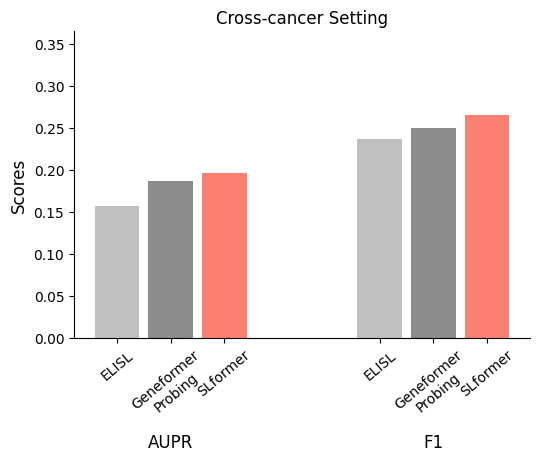

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the metrics and data for each model
metrics = ["AUPR", "F1"]
# models = ["Geneformer", "ELISL", "SLformer"]
models = ["ELISL", "Geneformer Probing", "SLformer"]



aupr_scores = [0.1571, 0.1863, 0.1956]
f1_scores = [0.2369, 0.2491, 0.2644]

# Group the scores
scores = [aupr_scores, f1_scores]

colors = [model_colors['ELISL'],model_colors['Geneformer Probing'], model_colors['SLformer']]

# Define the metrics and data for each model
metrics = ["AUPR", "F1"]
models = ["ELISL", "Geneformer Probing", "SLformer"]

# Multi-line model names
pretty_model_names = {
    "ELISL": "ELISL",
    "Geneformer Probing": "Geneformer\nProbing",
    "SLformer": "SLformer"
}


# Scores for each metric
aupr_scores = [0.1571, 0.1863, 0.1956]
f1_scores = [0.2369, 0.2491, 0.2644]
scores = [aupr_scores, f1_scores]

# Corresponding colors
colors = [model_colors['ELISL'],model_colors['Geneformer Probing'], model_colors['SLformer']]

# Create figure and axis
fig, ax = plt.subplots(figsize=(5.5, 5))

# X positions for bars
x = np.arange(len(metrics))
bar_width = 0.17
positions = [x - bar_width*1.2, x, x + bar_width*1.2]

# Determine y-axis range
min_value = min(min(aupr_scores), min(f1_scores)) - 0.1
max_value = max(max(aupr_scores), max(f1_scores)) + 0.1

# Make sure min_value is not less than 0
min_value = 0.00
max_value = min(max_value, 1)

# Y ticks
y_ticks_all = np.arange(0, 1.05, 0.05)
y_ticks = y_ticks_all[(y_ticks_all >= min_value) & (y_ticks_all <= max_value)]
if min_value not in y_ticks:
    y_ticks = np.append(y_ticks, min_value)

# Plot bars
for i, model in enumerate(models):
    ax.bar(positions[i], [scores[0][i], scores[1][i]],
           width=bar_width, label=model, color=colors[i])

# Set labels and title
ax.set_ylabel('Scores', fontsize=12)
# ax.set_title('Performance Comparison in Cross-cancer Setting')
ax.set_title('Cross-cancer Setting')

# X-tick labels (model names, repeated for each metric)
xtick_labels = [pretty_model_names[model] for model in models for _ in metrics]
flattened_positions = np.concatenate(positions)
ax.set_xticks(flattened_positions)
ax.set_xticklabels(xtick_labels, rotation=40)

# Metric names below
for i, metric in enumerate(metrics):
    ax.text(x[i], min_value - 0.13, metric, ha='center', fontsize=12)

# Y-axis formatting
ax.set_ylim(min_value, max_value)
ax.set_yticks(np.sort(y_ticks))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

# Styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show plot
plt.tight_layout()
plt.show()


/tmp/ipykernel_1645514/723629799.py:60: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
/tmp/ipykernel_1645514/723629799.py:60: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')


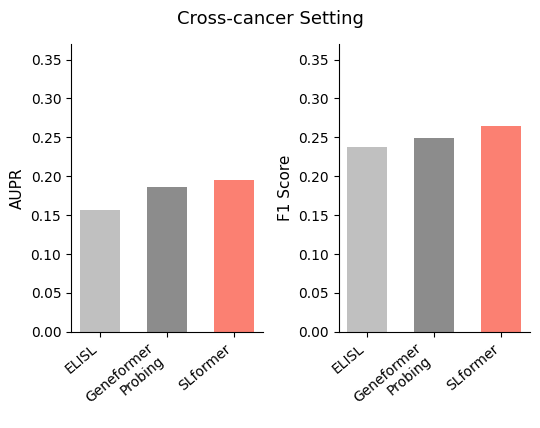

In [132]:
## 2 subplots

import numpy as np
import matplotlib.pyplot as plt

# Models and pretty names
models = ["ELISL", "Geneformer Probing", "SLformer"]
pretty_model_names = {
    "ELISL": "ELISL",
    "Geneformer Probing": "Geneformer\nProbing",
    "SLformer": "SLformer"
}

# Model colors
model_colors = {
    "GCATSL": '#e0e0e0',
    "ELISL": '#c0c0c0',
    "KG4SL": '#a6a6a6',
    "Geneformer Probing": '#8c8c8c',
    "MVGCN-iSL": '#7a7a7a',
    "SLformer": '#fb8072'
}
colors = [model_colors[m] for m in models]

# Scores
aupr_scores = [0.1571, 0.1863, 0.1956]
f1_scores = [0.2369, 0.2491, 0.2644]
scores = [aupr_scores, f1_scores]
metrics = ["AUPR", "F1 Score"]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(5.5, 4.6))

# min_val = max(min(metric_scores) - 0.1, 0)
# max_val = min(max(metric_scores) + 0.1, 1)

min_val = 0.0
max_val = 0.37

# Plot each metric separately
for idx, ax in enumerate(axes):
    metric_scores = scores[idx]
    metric_name = metrics[idx]

    # Y-axis limits and ticks
    # min_val = max(min(metric_scores) - 0.1, 0)
    # max_val = min(max(metric_scores) + 0.1, 1)
    y_ticks = np.arange(0, 1.05, 0.05)
    y_ticks = y_ticks[(y_ticks >= min_val) & (y_ticks <= max_val)]

    # Plot each model's bar
    for i, model in enumerate(models):
        ax.bar(pretty_model_names[model], metric_scores[i], color=colors[i], width=0.6)

    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_ylim(min_val, max_val)
    ax.set_yticks(np.sort(y_ticks))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
    ax.tick_params(axis='x', labelsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Global title
fig.suptitle("Cross-cancer Setting", fontsize=13, y=0.92)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## indep test plots

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import scipy.stats as stats

data = {
    'cancer': ['COAD']*5 + ['LAML']*5 + ['LUAD']*5 + ['COAD']*5 + ['LAML']*5 + ['LUAD']*5,
    'ndcg@10': [
        0.440173729, 0.530737022, 0.43300783, 0.736166019, 0.473165248,# 0.52264997,  # COAD (cancer specific)
        0.728631814, 0.717313357, 0.687489017, 0.861251401, 0.879387598,# 0.774814637,  # LAML (cancer specific)
        0.599532075, 0.533662375, 0.465786028, 0.701495994, 0.58332796, #0.576760886,  # LUAD (cancer specific)
        0.485822078, 0.668504435, 0.498705847, 0.522740195, 0.641976304, #0.563549772,  # COAD (mix cancer)
        0.79763028, 0.884910775, 0.34791631, 0.751694612, 0.645201405,# 0.685470677,  # LAML (mix cancer)
        0.68968243, 0.605366218, 0.628173221, 0.737969403, 0.491216333,# 0.630481521  # LUAD (mix cancer)
    ],
    'ndcg@20': [
        0.538491078, 0.567587325, 0.492477906, 0.673559554, 0.485330177,# 0.551489208,  # COAD (cancer specific)
        0.723786601, 0.658744652, 0.6712662, 0.730018818, 0.832404333,# 0.723244121,  # LAML (cancer specific)
        0.623086504, 0.572588631, 0.51845358, 0.626857489, 0.599143394,# 0.58802592,  # LUAD (cancer specific)
        0.549719674, 0.645234403, 0.456154169, 0.528762969, 0.632674192,# 0.562509082,  # COAD (mix cancer)
        0.79697215, 0.854916563, 0.399633183, 0.742553684, 0.622503071,# 0.68331573,  # LAML (mix cancer)
        0.680354837, 0.625655537, 0.608299558, 0.760188102, 0.520510559,# 0.639001719  # LUAD (mix cancer)
    ],
    'ndcg@30': [
        0.550117475, 0.566308808, 0.492246435, 0.631420733, 0.512181884,# 0.550455067,  # COAD (cancer specific)
        0.704781415, 0.638143016, 0.685008471, 0.731768414, 0.759416704,# 0.703823604,  # LAML (cancer specific)
        0.645030061, 0.577364688, 0.518185424, 0.639330585, 0.624484488, #0.600879049,  # LUAD (cancer specific)
        0.510233979, 0.626232658, 0.496439619, 0.581600355, 0.620795093,# 0.567060341,  # COAD (mix cancer)
        0.79945671, 0.756629589, 0.487171388, 0.677869211, 0.61047325,# 0.66632003,  # LAML (mix cancer)
        0.671601883, 0.619794524, 0.627966266, 0.726907208, 0.519584188,# 0.633170814  # LUAD (mix cancer)
    ],
    'ndcg@50': [
        0.543101439, 0.574027298, 0.547660115, 0.649263957, 0.574001526,# 0.577610867,  # COAD (cancer specific)
        0.671432419, 0.621338851, 0.643279631, 0.699317883, 0.731426327,# 0.673359022,  # LAML (cancer specific)
        0.64926058, 0.598034145, 0.574550518, 0.656661847, 0.661345123,# 0.627970443,  # LUAD (cancer specific)
        0.556343356, 0.584748656, 0.547591373, 0.579774136, 0.670117074,# 0.587714919,  # COAD (mix cancer)
        0.791025784, 0.666515495, 0.496893149, 0.642548709, 0.635310122,# 0.646458652,  # LAML (mix cancer)
        0.682266836, 0.665605738, 0.666657173, 0.741118849, 0.567464365,# 0.664622592  # LUAD (mix cancer)
    ],
    'ndcg@100': [
        0.660863589, 0.679841749, 0.639317131, 0.709913251, 0.663757653,# 0.670738675,  # COAD (cancer specific)
        0.649787005, 0.604082771, 0.635927745, 0.601196691, 0.604416881,# 0.619082219,  # LAML (cancer specific)
        0.674664495, 0.637904368, 0.642320351, 0.675583424, 0.69660741,# 0.66541601,  # LUAD (cancer specific)
        0.641821454, 0.664017972, 0.673041414, 0.638422653, 0.710368086,# 0.665534316,  # COAD (mix cancer)
        0.702897808, 0.624416882, 0.540285368, 0.569664094, 0.643524728, #0.616157776,  # LAML (mix cancer)
        0.709708058, 0.66416274, 0.727827073, 0.766837262, 0.654552354,# 0.704617498  # LUAD (mix cancer)
    ],
    'Type': ['cancer_specific']*15 + ['mix_cancer']*15  # Type label for each row
}

# Load data into DataFrame
df = pd.DataFrame(data)



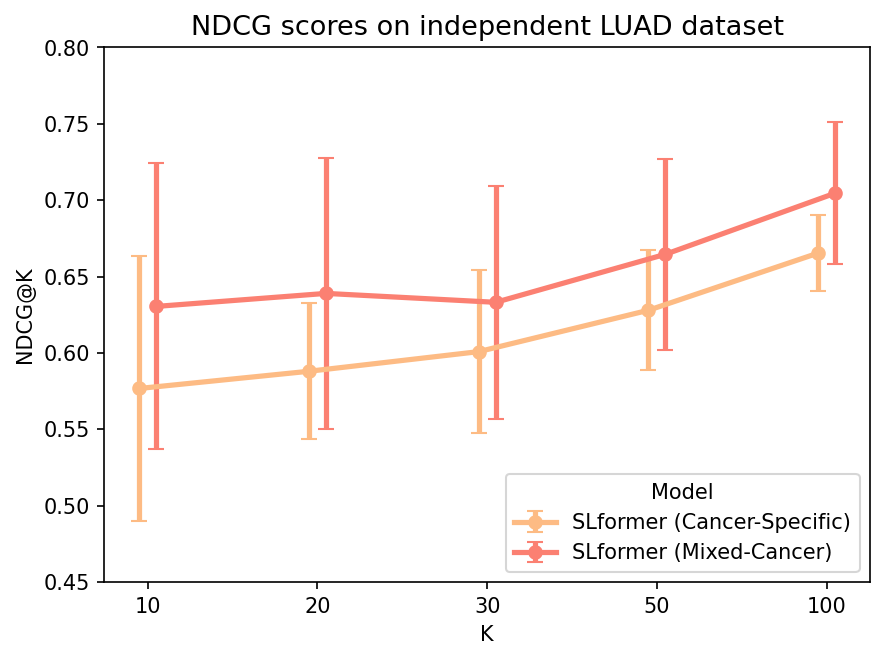

In [3]:
# Define K values and metrics
metrics = ["ndcg@10", "ndcg@20", "ndcg@30", "ndcg@50", "ndcg@100"]
x_labels = [10, 20, 30, 50, 100]
x_pos = np.arange(len(metrics))
offset = 0.05

cancer = 'LUAD'

plot_data_cancer = df[df['cancer'] == cancer]
df_list_new = []
for metric in metrics:
    df_1m = plot_data_cancer[['Type', metric]].copy()
    df_1m.columns = ['Type', 'ndcg_score']
    df_1m['metric'] = metric
    df_list_new.append(df_1m)
plot_data_sep = pd.concat(df_list_new, ignore_index=True)


summary = plot_data_sep.groupby(['Type', 'metric'])['ndcg_score'].agg(['mean', 'std']).reset_index()

# Sort metrics by the original order
metrics_order = ["ndcg@10", "ndcg@20", "ndcg@30", "ndcg@50", "ndcg@100"]
summary['metric'] = pd.Categorical(summary['metric'], categories=metrics_order, ordered=True)
summary = summary.sort_values(['Type', 'metric'])

# Get positions
x_pos = np.arange(len(metrics_order))
offset = 0.05

# Separate data
cancer_specific = summary[summary['Type'] == 'cancer_specific']
mix_cancer = summary[summary['Type'] == 'mix_cancer']

# Plot
plt.figure(figsize=(6, 4.5), dpi=150)

# cancer_specific: left
plt.errorbar(x_pos - offset, cancer_specific['mean'], yerr=cancer_specific['std'],
             fmt='o-', color='#fdbb84', capsize=4, label='SLformer (cancer-specific)', linewidth=2.5)

# mix_cancer: right
plt.errorbar(x_pos + offset, mix_cancer['mean'], yerr=mix_cancer['std'],
             fmt='o-', color='#fb8072', capsize=4, label='SLformer (mix-cancer)', linewidth=2.5)

# Rename legend labels and set location
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ['SLformer (Cancer-Specific)', 'SLformer (Mixed-Cancer)']
plt.legend(handles, new_labels, title='Model', fontsize=10, loc='lower right')

# Customized
plt.xticks(ticks=x_pos, labels=['10', '20', '30', '50', '100'])
plt.xlabel("K")
plt.ylabel("NDCG@K")
plt.title(f"NDCG scores on independent {cancer} dataset", fontsize=13)
plt.ylim(0.45, 0.8)
plt.tight_layout()
plt.show()




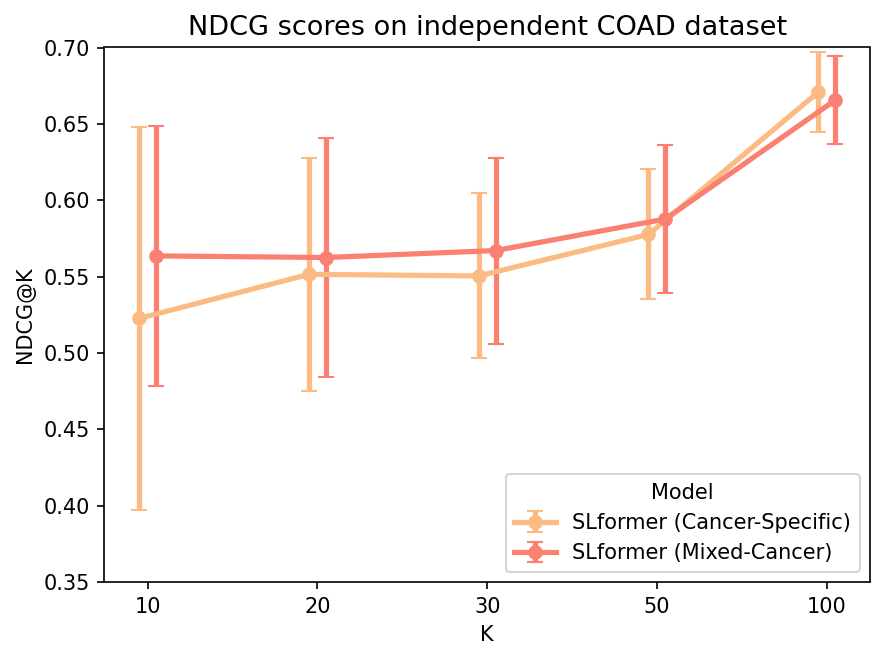

In [5]:
cancer = 'COAD'

plot_data_cancer = df[df['cancer'] == cancer]
df_list_new = []
for metric in metrics:
    df_1m = plot_data_cancer[['Type', metric]].copy()
    df_1m.columns = ['Type', 'ndcg_score']
    df_1m['metric'] = metric
    df_list_new.append(df_1m)
plot_data_sep = pd.concat(df_list_new, ignore_index=True)
summary = plot_data_sep.groupby(['Type', 'metric'])['ndcg_score'].agg(['mean', 'std']).reset_index()

# Sort metrics by the original order
metrics_order = ["ndcg@10", "ndcg@20", "ndcg@30", "ndcg@50", "ndcg@100"]
summary['metric'] = pd.Categorical(summary['metric'], categories=metrics_order, ordered=True)
summary = summary.sort_values(['Type', 'metric'])

# Get positions
x_pos = np.arange(len(metrics_order))
offset = 0.05

# Separate data
cancer_specific = summary[summary['Type'] == 'cancer_specific']
mix_cancer = summary[summary['Type'] == 'mix_cancer']

# Plot
plt.figure(figsize=(6, 4.5), dpi=150)

# cancer_specific: left
plt.errorbar(x_pos - offset, cancer_specific['mean'], yerr=cancer_specific['std'],
             fmt='o-', color='#fdbb84', capsize=4, label='SLformer (cancer-specific)', linewidth=2.5)

# mix_cancer: right
plt.errorbar(x_pos + offset, mix_cancer['mean'], yerr=mix_cancer['std'],
             fmt='o-', color='#fb8072', capsize=4, label='SLformer (mix-cancer)', linewidth=2.5)

# Rename legend labels and set location
handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ['SLformer (Cancer-Specific)', 'SLformer (Mixed-Cancer)']
plt.legend(handles, new_labels, title='Model', fontsize=10, loc='lower right')

# Customized
plt.xticks(ticks=x_pos, labels=['10', '20', '30', '50', '100'])
plt.xlabel("K")
plt.ylabel("NDCG@K")
plt.title(f"NDCG scores on independent {cancer} dataset", fontsize=13)
plt.ylim(0.35, 0.70) # COAD
plt.tight_layout()
plt.show()




## Ranking of contexts for SL gene pairs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data_dict_updated = {
    "study": ["paralog_study1_score"] * 5 + ["paralog_study2_score"] * 5,
    "model_fold": [0, 1, 2, 3, 4, 0, 1, 2, 3, 4],
    "cancer_specific": [
        0.4550561797752809, 0.4269662921348314, 0.398876404494382,
        0.4606741573033708, 0.4325842696629213,
        0.2810810810810811, 0.2756756756756757, 0.2972972972972973,
        0.3027027027027027, 0.3189189189189189
    ],
    "mix": [
        0.3932584269662921, 0.4550561797752809, 0.4775280898876404,
        0.5, 0.4831460674157303,
        0.3081081081081081, 0.3621621621621622, 0.3351351351351351,
        0.372972972972973, 0.3405405405405405
    ]
}

df = pd.DataFrame(data_dict_updated)

# Calculate mean and standard deviation for each study
summary_df = df.groupby("study").agg(
    cancer_specific_mean=("cancer_specific", "mean"),
    cancer_specific_std=("cancer_specific", "std"),
    mix_mean=("mix", "mean"),
    mix_std=("mix", "std")
).reset_index()


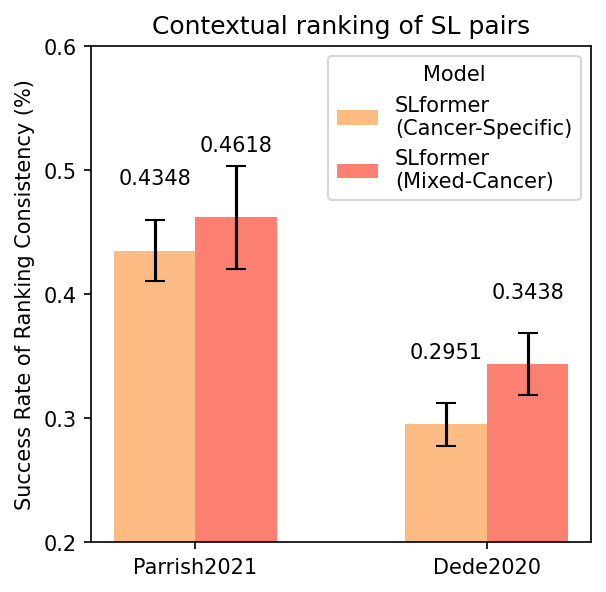

In [ ]:
## cancer_specific vs mixed_cancer
custom_palette = {'cancer_specific': '#fdbb84',  
                  'mix_cancer': '#fb8072'}  

study_labels = {
    "paralog_study1_score": "Parrish2021",
    "paralog_study2_score": "Dede2020"
}

# Update labels in summary dataframe
summary_df['study_label'] = summary_df['study'].map(study_labels)

# Plot with updated labels
# fig, ax = plt.subplots(figsize=(3.7, 4.3), dpi=150)
fig, ax = plt.subplots(figsize=(4.3, 4.3), dpi=150)

# Bar width
bar_width = 0.14
x = np.arange(len(summary_df)) * 0.5


bars1 = ax.bar(x - bar_width/2, summary_df['cancer_specific_mean'], bar_width,
               yerr=summary_df['cancer_specific_std'], capsize=5, label="SLformer\n(Cancer-Specific)",
               color=custom_palette['cancer_specific'])

bars2 = ax.bar(x + bar_width/2, summary_df['mix_mean'], bar_width,
               yerr=summary_df['mix_std'], capsize=5, label="SLformer\n(Mixed-Cancer)",
               color=custom_palette['mix_cancer'])

# Add labels on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.05, f"{height:.4f}",
            ha='center', va='bottom', fontsize=10)

ax.grid(False)  
# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(summary_df['study_label'], rotation=0)
# ax.set_ylabel("Exact Matching Accuracy")
# ax.set_ylabel("Success Rate (%)")
ax.set_ylabel("Success Rate of Ranking Consistency (%)")
# ax.set_xlabel("Study")
ax.set_xlabel("")
# ax.set_ylim(0.4, 0.95)
ax.set_ylim(0.2, 0.6)
ax.set_yticks(np.arange(0.2, 0.61, 0.1))
ax.legend(title="Model")
# ax.set_title("SL Effect Ranking Across Cancers")
# ax.set_title("SL Penetrance Consistence")
ax.set_title("Contextual ranking of SL pairs")

# Show the plot
plt.show()


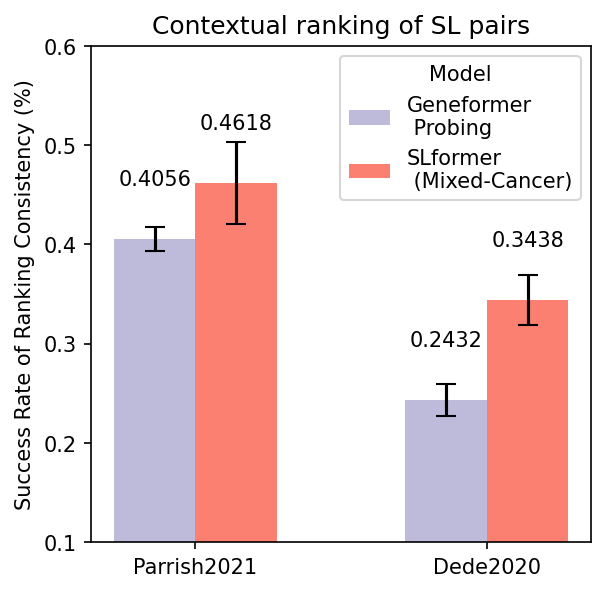

In [ ]:
## Geneformer Probing vs SLformer
import pandas as pd

custom_palette = {'Geneformer Probing': '#bebada',  
                'SLformer': '#fb8072'} 

# Updated SLformer vs Geneformer experiment data
data_dict_new = {
    "study": ["paralog_study1_score"] * 5 + ["paralog_study2_score"] * 5,
    "model_fold": [0, 1, 2, 3, 4, 0, 1, 2, 3, 4],
    "SLformer": [
        0.3932584269662921, 0.4550561797752809, 0.4775280898876404,
        0.5, 0.4831460674157303,
        0.3081081081081081, 0.3621621621621622, 0.3351351351351351,
        0.372972972972973, 0.3405405405405405
    ],
    "Geneformer": [
        0.4044943820224719, 0.4101123595505618, 0.3876404494382022,
        0.4213483146067415, 0.4044943820224719,
        0.2216216216216216, 0.2486486486486486, 0.2378378378378378,
        0.2648648648648649, 0.2432432432432432
    ]
}

df = pd.DataFrame(data_dict_new)

# Calculate mean and standard deviation for each study
summary_df = df.groupby("study").agg(
    slformer_mean=("SLformer", "mean"),
    slformer_std=("SLformer", "std"),
    geneformer_mean=("Geneformer", "mean"),
    geneformer_std=("Geneformer", "std")
).reset_index()

study_labels = {
    "paralog_study1_score": "Parrish2021",
    "paralog_study2_score": "Dede2020"
}

# Update labels in summary dataframe
summary_df['study_label'] = summary_df['study'].map(study_labels)



# Plot with updated labels
# fig, ax = plt.subplots(figsize=(3.7, 4.3), dpi=150)
# fig, ax = plt.subplots(figsize=(3.7, 8), dpi=150)
fig, ax = plt.subplots(figsize=(4.3, 4.3), dpi=150)

# Bar width
bar_width = 0.14 # 0.17
x = np.arange(len(summary_df)) * 0.5

# Plot bars

bars1 = ax.bar(x - bar_width/2, summary_df['geneformer_mean'], bar_width,
               yerr=summary_df['geneformer_std'], capsize=5, label="Geneformer\n Probing",
               color=custom_palette['Geneformer Probing'])

bars2 = ax.bar(x + bar_width/2, summary_df['slformer_mean'], bar_width,
               yerr=summary_df['slformer_std'], capsize=5, label="SLformer\n (Mixed-Cancer)",
               color=custom_palette['SLformer'])


# Add labels on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.05, f"{height:.4f}",
            ha='center', va='bottom', fontsize=10)

ax.grid(False)  # Turns off both major and minor grid lines
# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(summary_df['study_label'], rotation=0)
# ax.set_ylabel("Exact Matching Accuracy")
# ax.set_ylabel("Success Rate (%)")
ax.set_ylabel("Success Rate of Ranking Consistency (%)")
# ax.set_xlabel("Study")
ax.set_xlabel("")
# ax.set_ylim(0.35, 0.95)
# ax.set_yticks(np.arange(0.35, 0.96, 0.05))
ax.set_ylim(0.2, 0.6)
ax.set_yticks(np.arange(0.1, 0.61, 0.1))
ax.legend(title="Model")
# ax.set_title("SL Effect Ranking Across Cancers")
# ax.set_title("SL Penetrance Consistence")
ax.set_title("Contextual ranking of SL pairs") 

# Show the plot
plt.show()


## Ablation study plots

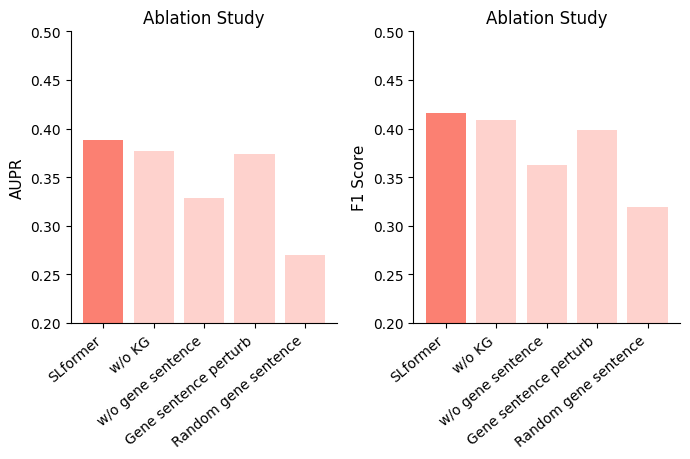

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "SLformer",
    "w/o KG",
    "w/o gene sentence",
    "Gene sentence perturb",
    "Random gene sentence"
]

aupr_means = [0.3879, 0.3767, 0.3288, 0.3735, 0.2696]
aupr_stds = [0.0122, 0.0137, 0.0139, 0.0076, 0.0892]

f1_means = [0.4162, 0.4084, 0.3624, 0.3990, 0.3188]
f1_stds = [0.0139, 0.0154, 0.0125, 0.0137, 0.0647]

bar_width = 0.8
x = np.arange(len(models))

colors = ['#fb8072' if model == "SLformer" else '#fed2cd' for model in models]

# Create separate plots for AUPR and F1 scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4.7))

# Set y-axis range
y_min, y_max = 0.2, 0.5

# Plot AUPR
ax1.bar(x, aupr_means, bar_width, capsize=5, color=colors)
ax1.set_ylabel("AUPR", fontsize=11)
ax1.set_title("Ablation Study")
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=40, ha="right")
ax1.set_ylim(y_min, y_max)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot F1
ax2.bar(x, f1_means, bar_width, capsize=5, color=colors)
ax2.set_ylabel("F1 Score", fontsize=11)
ax2.set_title("Ablation Study")
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=40, ha="right")
ax2.set_ylim(y_min, y_max)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


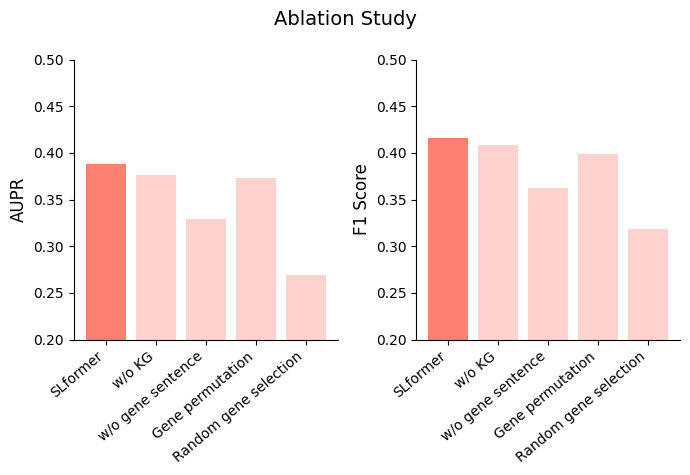

In [9]:
## 2 subplots

import matplotlib.pyplot as plt
import numpy as np

models = [
    "SLformer",
    "w/o KG",
    "w/o gene sentence",
    "Gene permutation",
    "Random gene selection"
]

aupr_means = [0.3879, 0.3767, 0.3288, 0.3735, 0.2696]
aupr_stds = [0.0122, 0.0137, 0.0139, 0.0076, 0.0892]

f1_means = [0.4162, 0.4084, 0.3624, 0.3990, 0.3188]
f1_stds = [0.0139, 0.0154, 0.0125, 0.0137, 0.0647]

bar_width = 0.8
x = np.arange(len(models))

colors = ['#fb8072' if model == "SLformer" else '#fed2cd' for model in models]

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 5))

# Shared Y-axis range
y_min, y_max = 0.2, 0.5

# AUPR subplot
ax1.bar(x, aupr_means, bar_width, capsize=5, color=colors)
ax1.set_ylabel("AUPR", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=40, ha="right")
ax1.set_ylim(y_min, y_max)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# F1 subplot
ax2.bar(x, f1_means, bar_width, capsize=5, color=colors)
ax2.set_ylabel("F1 Score", fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=40, ha="right")
ax2.set_ylim(y_min, y_max)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Shared title
fig.suptitle("Ablation Study", fontsize=14, y=0.94)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
